# MeshivGauli_2432211

# Sentiment Analysis using Recurrent Neural Networks (RNN)

## Overview

This notebook presents an end-to-end Natural Language Processing (NLP) workflow for sentiment analysis using deep learning. The project focuses on classifying text sentiments by progressively building and evaluating different recurrent neural network architectures.

Three deep learning models are implemented and compared:

- **Model 1:** Simple RNN with a trainable Embedding layer
- **Model 2:** LSTM with a trainable Embedding layer
- **Model 3:** LSTM with pre-trained Word2Vec embeddings

Throughout the notebook, the complete NLP pipeline is demonstrated, including:

- Text cleaning and preprocessing
- Tokenization and sequence padding
- Training, validation, and testing data preparation
- Building RNN and LSTM-based text classification models
- Model evaluation using accuracy, precision, recall, F1-score, and confusion matrices
- Comparative analysis of different recurrent architectures and embedding techniques
- Error analysis of misclassified examples
- Real-time sentiment prediction using a simple graphical user interface (GUI)

The objective of this project is to investigate how different recurrent neural network architectures and embedding strategies influence sentiment classification performance while gaining practical experience with modern deep learning techniques for Natural Language Processing.

In [ ]:
# Install required libraries
!pip install contractions wordcloud nltk gensim gradio -q

# Basic utilities
import time
import re
import contractions
import numpy as np
import pandas as pd

# Visualization tools
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# NLP preprocessing tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Deep learning framework (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Pretrained word embeddings loader (Gensim)
import gensim.downloader as api


In [ ]:
# Download required NLTK datasets
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Text Preprocessing, Tokenization, and Sequence Padding:

### Load the dataset:

In [ ]:
# Mount Google Drive (Colab environment)
from google.colab import drive
drive.mount('/content/drive')

# File paths for dataset
train_data_path = "/content/drive/MyDrive/AIIIIIIIII/Dataset/train_racisit.csv"
test_data_path = "/content/drive/MyDrive/AIIIIIIIII/Dataset/test_racisit.csv"

# Load datasets
train_data = pd.read_csv(train_data_path)
test_data = pd.read_csv(test_data_path)

# Print dataset shapes for verification
print(f"Training dataset shape: {train_data.shape}")
print(f"Testing dataset shape: {test_data.shape}")

# Preview training dataset
train_data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training dataset shape: (31962, 3)
Testing dataset shape: (17197, 2)


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


Dataset columns:
Index(['id', 'label', 'tweet'], dtype='object')

Missing values per column:
id       0
label    0
tweet    0
dtype: int64

Number of duplicate rows: 0

Class distribution (counts):
label
0    29720
1     2242
Name: count, dtype: int64

Class distribution (percentage):
label
0    92.98542
1     7.01458
Name: proportion, dtype: float64


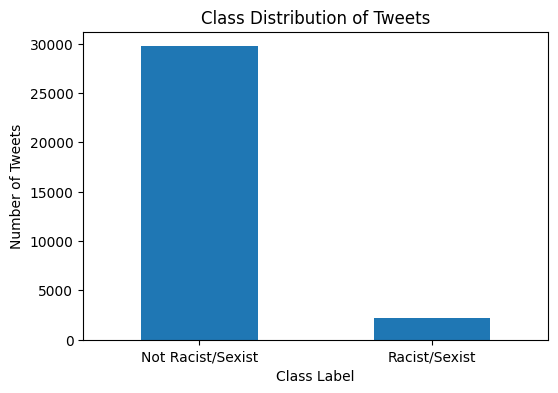

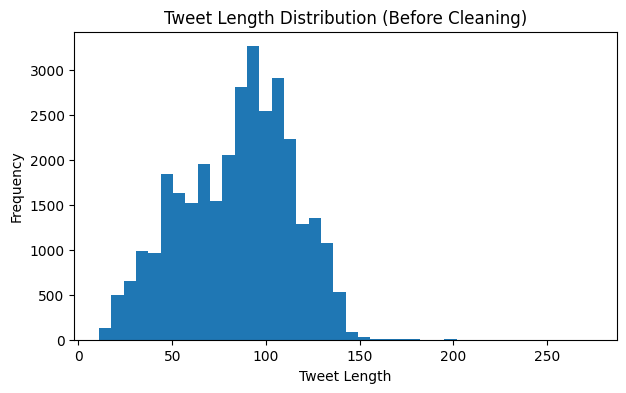


Tweet length statistics:
count    31962.000000
mean        84.739628
std         29.455749
min         11.000000
25%         63.000000
50%         88.000000
75%        108.000000
max        274.000000
Name: tweet_length, dtype: float64


In [ ]:
# Overview of dataset columns
print("Dataset columns:")
print(train_data.columns)

# Check for missing values in each column
print("\nMissing values per column:")
print(train_data.isnull().sum())

# Check for duplicate rows in dataset
duplicate_count = train_data.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

# Class distribution (raw counts)
class_counts = train_data['label'].value_counts()
print("\nClass distribution (counts):")
print(class_counts)

# Class distribution (percentage)
class_percentages = train_data['label'].value_counts(normalize=True) * 100
print("\nClass distribution (percentage):")
print(class_percentages)

# Visualize class distribution
plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar')
plt.title("Class Distribution of Tweets")
plt.xlabel("Class Label")
plt.ylabel("Number of Tweets")
plt.xticks(
    ticks=[0, 1],
    labels=["Not Racist/Sexist", "Racist/Sexist"],
    rotation=0
)
plt.show()

# Create a feature for tweet length (before preprocessing)
train_data['tweet_length'] = train_data['tweet'].astype(str).apply(len)

# Visualize tweet length distribution
plt.figure(figsize=(7, 4))
plt.hist(train_data['tweet_length'], bins=40)
plt.title("Tweet Length Distribution (Before Cleaning)")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")
plt.show()

# Summary statistics of tweet lengths
print("\nTweet length statistics:")
print(train_data['tweet_length'].describe())

### Clean the text:

In [ ]:
# Text preprocessing setup
stop_words_set = set(stopwords.words('english'))
word_lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()

    # Expand contractions (e.g., "don't" → "do not")
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove user mentions (@user)
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove digits
    text = re.sub(r"\d+", "", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-z\s]", "", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize text
    tokens = text.split()

    # Remove stopwords and apply lemmatization
    tokens = [
        word_lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words_set and len(word) > 2
    ]

    return " ".join(tokens)

In [ ]:
# Apply preprocessing to training and test data
train_data['clean_text'] = train_data['tweet'].apply(preprocess_text)
test_data['clean_text'] = test_data['tweet'].apply(preprocess_text)

# Preview cleaned data
train_data[['tweet', 'clean_text', 'label']].head(10)

,tweet,clean_text,label
0,@user when a father is dysfunctional and is s...,father dysfunctional selfish drag kid dysfunct...,0
1,@user @user thanks for #lyft credit i can't us...,thanks lyft credit cannot use offer wheelchair...,0
2,bihday your majesty,bihday majesty,0
3,#model i love u take with u all the time in ...,model love take time,0
4,factsguide: society now #motivation,factsguide society motivation,0
5,[2/2] huge fan fare and big talking before the...,huge fan fare big talking leave chaos pay disp...,0
6,@user camping tomorrow @user @user @user @use...,camping tomorrow danny,0
7,the next school year is the year for exams.ð...,next school year year exam cannot think school...,0
8,we won!!! love the land!!! #allin #cavs #champ...,love land allin cavs champion cleveland clevel...,0
9,@user @user welcome here ! i'm it's so #gr...,welcome,0


In [ ]:
# Count empty cleaned tweets
empty_cleaned_count = (train_data['clean_text'].str.strip() == "").sum()
print(f"Empty tweets after preprocessing: {empty_cleaned_count}")

# Remove empty rows after cleaning
train_data = train_data[train_data['clean_text'].str.strip() != ""]

print(f"Training data shape after removing empty tweets: {train_data.shape}")

Empty tweets after preprocessing: 48
Training data shape after removing empty tweets: (31914, 5)


### Visualize the cleaned data:

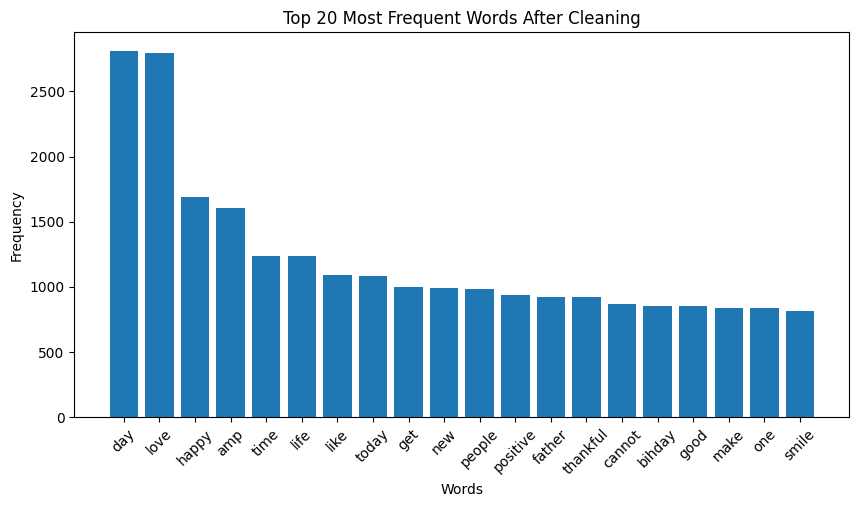

In [ ]:
# Combine all cleaned tweets into a single corpus
all_text = " ".join(train_data['clean_text'])
all_tokens = all_text.split()

# Count word frequencies
word_freq = Counter(all_tokens)
top_words = word_freq.most_common(20)

words, frequencies = zip(*top_words)

# Plot most frequent words
plt.figure(figsize=(10, 5))
plt.bar(words, frequencies)
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

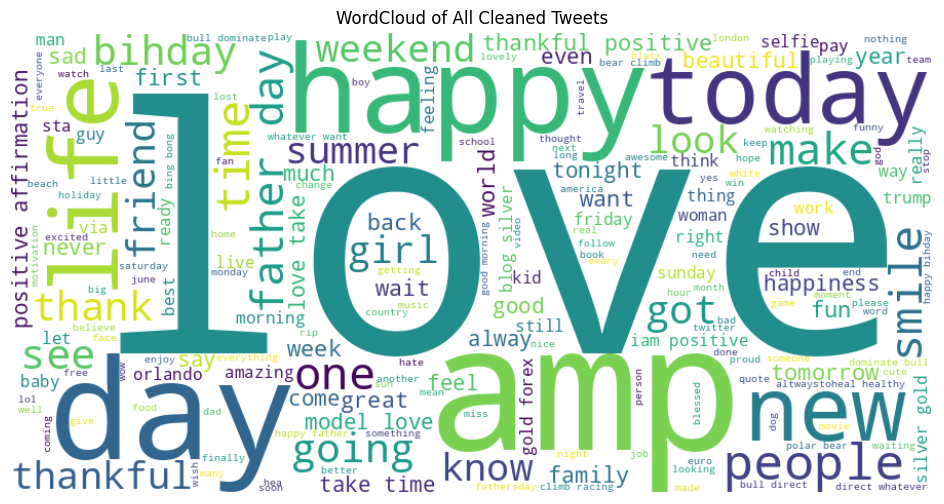

In [ ]:
# WordCloud for all tweets

# Generate word cloud for entire dataset
wordcloud_all = WordCloud(
    width=900,
    height=450,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_all, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud of All Cleaned Tweets")
plt.show()

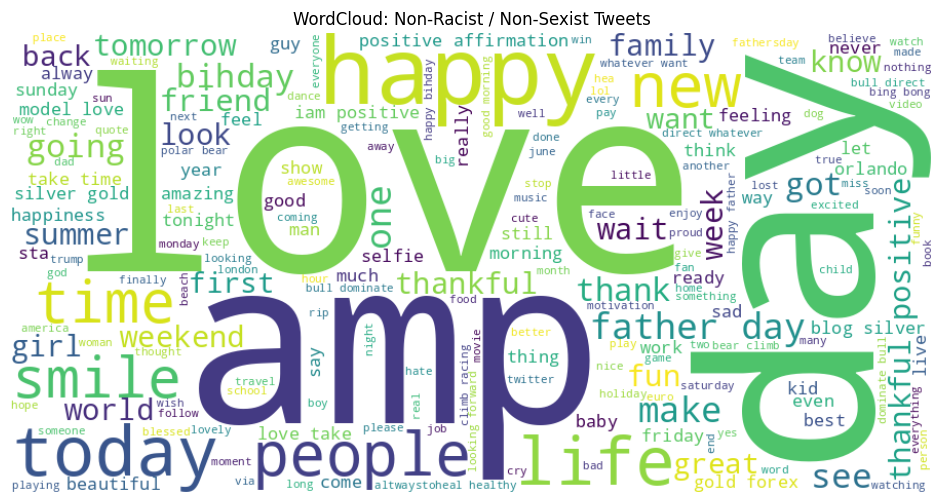

In [ ]:
# WordCloud for non-hate tweets

# Filter non-hate tweets
non_hate_text = " ".join(train_data[train_data['label'] == 0]['clean_text'])

wordcloud_non_hate = WordCloud(
    width=900,
    height=450,
    background_color='white'
).generate(non_hate_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_non_hate, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud: Non-Racist / Non-Sexist Tweets")
plt.show()

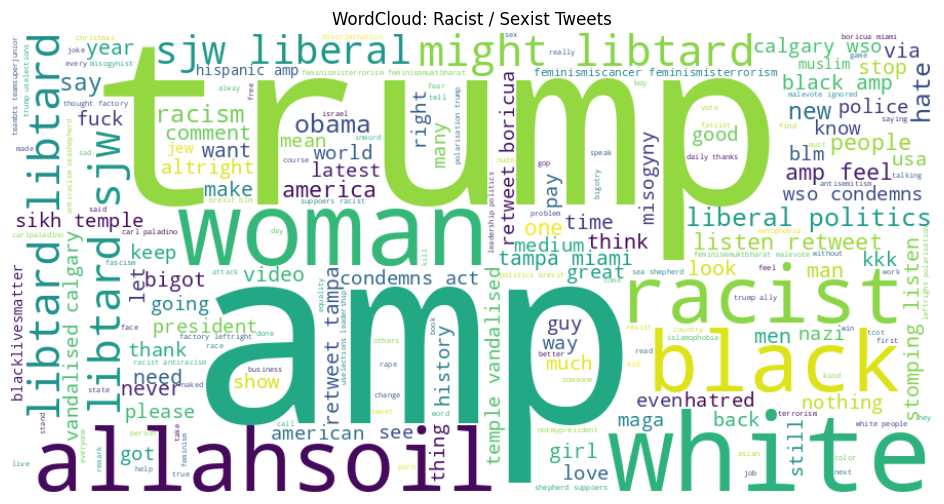

In [ ]:
# WordCloud for hate tweets

# Filter hate tweets
hate_text = " ".join(train_data[train_data['label'] == 1]['clean_text'])

wordcloud_hate = WordCloud(
    width=900,
    height=450,
    background_color='white'
).generate(hate_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_hate, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud: Racist / Sexist Tweets")
plt.show()

### Tokenization and Padding:

In [ ]:
# Separate features (text) and target (labels)
texts = train_data['clean_text'].values
labels = train_data['label'].values

# Split data into training and validation sets (80/20 split)
X_train, X_val, y_train, y_val = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Training samples: 25531
Validation samples: 6383


In [ ]:
# Tokenization

# Define vocabulary size for tokenizer
vocab_size = 10000

# Initialize tokenizer with OOV handling
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")

# Learn vocabulary from training data only
tokenizer.fit_on_texts(X_train)

# Convert text into integer sequences
train_sequences = tokenizer.texts_to_sequences(X_train)
val_sequences = tokenizer.texts_to_sequences(X_val)

In [ ]:
# Sequence length selection

# Calculate sequence lengths from training data
sequence_lengths = [len(seq) for seq in train_sequences]

# Use 95th percentile as max sequence length (reduces padding waste)
max_length = int(np.percentile(sequence_lengths, 95))

print(f"Selected max sequence length (95th percentile): {max_length}")

Selected max sequence length (95th percentile): 12


In [ ]:
# Padding sequences

# Pad and truncate sequences to uniform length
X_train_pad = pad_sequences(
    train_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    val_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print(f"Training data shape after padding: {X_train_pad.shape}")
print(f"Validation data shape after padding: {X_val_pad.shape}")

Training data shape after padding: (25531, 12)
Validation data shape after padding: (6383, 12)


### Handling Class Imbalance
The dataset is heavily imbalanced, with far more non-racist tweets than racist/sexist ones. To prevent the model from becoming biased toward the larger class, we use class weights during training. This encourages the model to focus more on the smaller, more critical class.



In [ ]:
# Get unique class labels from training data
class_labels = np.unique(y_train)

# Compute balanced class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=y_train
)

# Convert to dictionary format required by Keras
class_weight_dict = dict(zip(class_labels, class_weights))

# Display dataset distribution
print("CLASS WEIGHTS SUMMARY")

print("\nClass distribution:")
print(f"Class 0 (Not Hate): {np.sum(y_train == 0)} samples")
print(f"Class 1 (Hate): {np.sum(y_train == 1)} samples")

print("\nComputed class weights:")
print(class_weight_dict)

print("\nIndividual weights:")
print(f"Class 0 (Not Hate): {class_weight_dict[0]:.4f}")
print(f"Class 1 (Hate): {class_weight_dict[1]:.4f}")

CLASS WEIGHTS SUMMARY

Class distribution:
Class 0 (Not Hate): 23741 samples
Class 1 (Hate): 1790 samples

Computed class weights:
{np.int64(0): np.float64(0.5376984962722716), np.int64(1): np.float64(7.131564245810056)}

Individual weights:
Class 0 (Not Hate): 0.5377
Class 1 (Hate): 7.1316


# Model Building and Training:

1. Simple RNN with a trainable Embedding layer.

In [ ]:
# Build Simple RNN model
print("Building Simple RNN model...")

model_rnn = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_length=max_length),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile model
model_rnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Building Simple RNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Stop training when validation loss stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Save best model during training
checkpoint_rnn = ModelCheckpoint(
    "best_rnn_model.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

In [ ]:
print("Training Simple RNN model...")

start_time = time.time()

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, checkpoint_rnn],
    verbose=1
)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

Training Simple RNN model...
Epoch 1/10
397/399 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7865 - loss: 0.5491
Epoch 1: val_loss improved from None to 0.35425, saving model to best_rnn_model.keras

Epoch 1: finished saving model to best_rnn_model.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8225 - loss: 0.4396 - val_accuracy: 0.8385 - val_loss: 0.3543
Epoch 2/10
395/399 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9454 - loss: 0.1576
Epoch 2: val_loss improved from 0.35425 to 0.15771, saving model to best_rnn_model.keras

Epoch 2: finished saving model to best_rnn_model.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9442 - loss: 0.1570 - val_accuracy: 0.9452 - val_loss: 0.1577
Epoch 3/10
397/399 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9775 - loss: 0.0682
Epoch 3: val_loss did not improve from 0.15771
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9740 - loss: 0.0764 - val_accuracy: 0.9267 - val_loss: 0.2319
Epoch 4/10
399/399 ━

In [ ]:
# Load best saved RNN model
model_rnn = tf.keras.models.load_model("best_rnn_model.keras")

print("Best model loaded successfully.")


Best model loaded successfully.


2. LSTM with a trainable Embedding layer.

In [ ]:
# Build LSTM model
print("Building LSTM model...")

model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=100, input_length=max_length),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile model
model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Building LSTM model...


In [ ]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Save best model during training
checkpoint_lstm = ModelCheckpoint(
    "best_lstm_model.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

In [ ]:
print("Training LSTM model...")

start_time = time.time()

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, checkpoint_lstm],
    verbose=1
)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

Training LSTM model...
Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7222 - loss: 0.5404
Epoch 1: val_loss improved from None to 0.22578, saving model to best_lstm_model.keras

Epoch 1: finished saving model to best_lstm_model.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.8102 - loss: 0.4224 - val_accuracy: 0.9204 - val_loss: 0.2258
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9277 - loss: 0.1984
Epoch 2: val_loss improved from 0.22578 to 0.16543, saving model to best_lstm_model.keras

Epoch 2: finished saving model to best_lstm_model.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9316 - loss: 0.1865 - val_accuracy: 0.9279 - val_loss: 0.1654
Epoch 3/10
397/399 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9620 - loss: 0.1082
Epoch 3: val_loss did not improve from 0.16543
399/399 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9579 - loss: 0.1144 - val_accuracy: 0.9239 - val_loss: 0.2176
Epoch 4/10
398/399 ━━━

In [ ]:
# Load best saved LSTM model
model_lstm = tf.keras.models.load_model("best_lstm_model.keras")

print("Best LSTM model loaded successfully.")

Best LSTM model loaded successfully.


3. LSTM with pretrained Word2Vec embeddings.

In [ ]:
# Load pretrained Word2Vec embeddings
print("Loading pretrained Word2Vec model (Google News 300)...")

word2vec = api.load("word2vec-google-news-300")

embedding_dim = 300
word_index = tokenizer.word_index

# Initialize embedding matrix with zeros
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Fill embedding matrix with pretrained vectors
for word, idx in word_index.items():
    if idx < vocab_size:
        if word in word2vec:
            embedding_matrix[idx] = word2vec[word]

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Loading pretrained Word2Vec model (Google News 300)...
Embedding matrix shape: (10000, 300)


In [ ]:
# LSTM model using pretrained embeddings
print("Building LSTM model with Word2Vec embeddings...")

model_w2v = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length,
        weights=[embedding_matrix],
        trainable=False  # freeze pretrained embeddings
    ),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile model
model_w2v.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Building LSTM model with Word2Vec embeddings...


In [ ]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Save best model
checkpoint_w2v = ModelCheckpoint(
    "best_w2v_model.keras",
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

In [ ]:
print("Training LSTM with Word2Vec embeddings...")

start_time = time.time()

history_w2v = model_w2v.fit(
    X_train_pad,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stopping, checkpoint_w2v],
    verbose=1
)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

Training LSTM with Word2Vec embeddings...
Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8149 - loss: 0.5064
Epoch 1: val_loss improved from None to 0.30587, saving model to best_w2v_model.keras

Epoch 1: finished saving model to best_w2v_model.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.8365 - loss: 0.4278 - val_accuracy: 0.8755 - val_loss: 0.3059
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8588 - loss: 0.3516
Epoch 2: val_loss improved from 0.30587 to 0.29333, saving model to best_w2v_model.keras

Epoch 2: finished saving model to best_w2v_model.keras
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8622 - loss: 0.3378 - val_accuracy: 0.8756 - val_loss: 0.2933
Epoch 3/10
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8701 - loss: 0.3035
Epoch 3: val_loss did not improve from 0.29333
399/399 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.8697 - loss: 0.3058 - val_accuracy: 0.8473 - val_loss: 0.3451
Epoch 4

In [ ]:
model_w2v = tf.keras.models.load_model("best_w2v_model.keras")

print("Best Word2Vec LSTM model loaded successfully.")

Best Word2Vec LSTM model loaded successfully.


# Model Evaluations:

In [ ]:
# Generate predictions on validation set (threshold = 0.5 for binary classification)
y_pred_rnn = (model_rnn.predict(X_val_pad) > 0.5).astype(int)
y_pred_lstm = (model_lstm.predict(X_val_pad) > 0.5).astype(int)
y_pred_w2v = (model_w2v.predict(X_val_pad) > 0.5).astype(int)

print("\nMODEL PERFORMANCE REPORT (Validation Set)")
print("=" * 60)

# Classification reports for each model
print("\nSimple RNN Model:\n")
print(classification_report(y_val, y_pred_rnn, target_names=['Not Hate', 'Hate']))

print("\nLSTM Model:\n")
print(classification_report(y_val, y_pred_lstm, target_names=['Not Hate', 'Hate']))

print("\nWord2Vec + LSTM Model:\n")
print(classification_report(y_val, y_pred_w2v, target_names=['Not Hate', 'Hate']))


# Function to compute evaluation metrics from confusion matrix
def calculate_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1_score = (2 * precision * recall / (precision + recall)) if (precision + recall) != 0 else 0

    return accuracy, precision, recall, f1_score


# Compute metrics for all models
results = {
    "Simple RNN": calculate_metrics(y_val, y_pred_rnn),
    "LSTM": calculate_metrics(y_val, y_pred_lstm),
    "Word2Vec + LSTM": calculate_metrics(y_val, y_pred_w2v)
}

# Display comparison table
print("\nMODEL COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Model':<20}{'Accuracy':<12}{'Precision':<12}{'Recall':<12}{'F1-score':<12}")
print("-" * 70)

for model_name, (acc, prec, rec, f1) in results.items():
    print(f"{model_name:<20}{acc:<12.4f}{prec:<12.4f}{rec:<12.4f}{f1:<12.4f}")

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step

MODEL PERFORMANCE REPORT (Validation Set)

Simple RNN Model:

              precision    recall  f1-score   support

    Not Hate       0.98      0.96      0.97      5935
        Hate       0.59      0.68      0.64       448

    accuracy                           0.95      6383
   macro avg       0.78      0.82      0.80      6383
weighted avg       0.95      0.95      0.95      6383


LSTM Model:

              precision    recall  f1-score   support

    Not Hate       0.98      0.95      0.97      5935
        Hate       0.54      0.72      0.62       448

    accuracy                           0.94      6383
   macro avg       0.76      0.84      0.79      6383
weighted avg       0.95      0.94      0.94      6383


Word2Vec + LSTM Model:

              precision    recall  f1-score   support

    Not Hate       0.98      0.91      0.94      5935
        Hat

### Training Curves Plot
Training vs. Validation loss and accuracy over epochs.

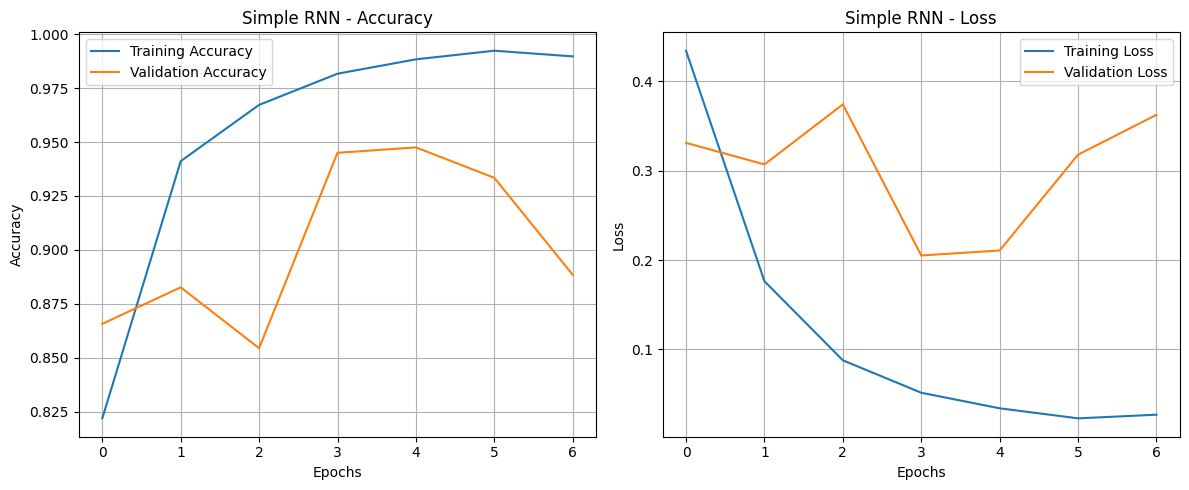

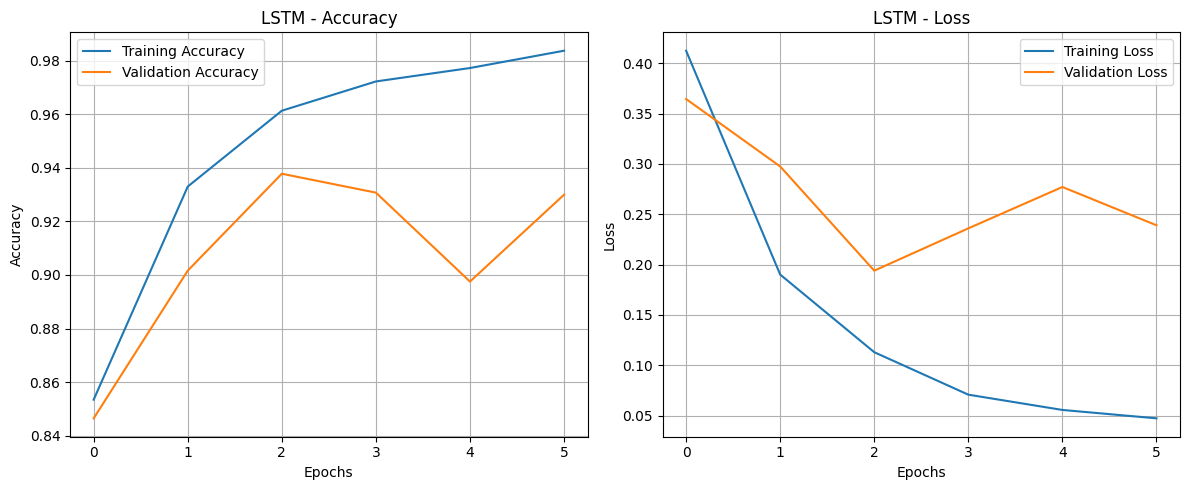

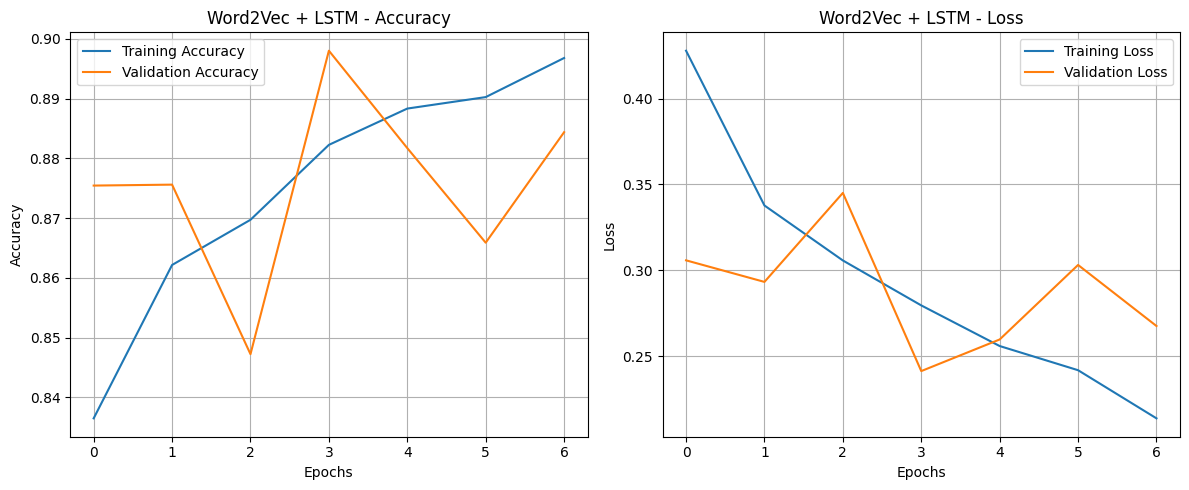

In [ ]:
def plot_training_curves(history, model_name):
    """
    Plots training vs validation accuracy and loss curves for a model.
    """

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy plot
    if 'accuracy' in history.history:
        axes[0].plot(history.history['accuracy'], label='Training Accuracy')
    if 'val_accuracy' in history.history:
        axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')

    axes[0].set_title(f'{model_name} - Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # Loss plot
    axes[1].plot(history.history['loss'], label='Training Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')

    axes[1].set_title(f'{model_name} - Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_training_curves(history_rnn, 'Simple RNN')
plot_training_curves(history_lstm, 'LSTM')
plot_training_curves(history_w2v, 'Word2Vec + LSTM')

### Confusion Matrices

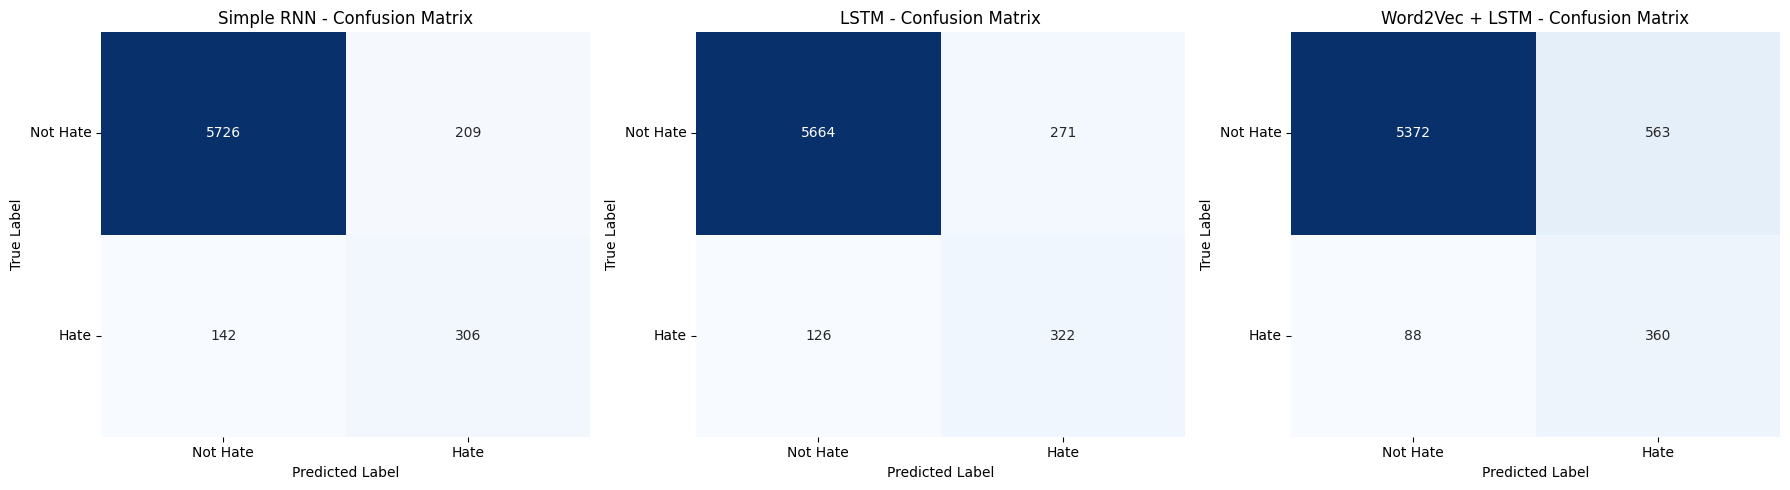

In [ ]:
def plot_confusion_matrix(ax, y_true, y_pred, title):
    """
    Plots confusion matrix on a given axis.
    """
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        cbar=False
    )

    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    ax.set_xticklabels(['Not Hate', 'Hate'])
    ax.set_yticklabels(['Not Hate', 'Hate'], rotation=0)


# Create subplots for 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Simple RNN
plot_confusion_matrix(
    axes[0],
    y_val,
    y_pred_rnn,
    "Simple RNN - Confusion Matrix"
)

# LSTM
plot_confusion_matrix(
    axes[1],
    y_val,
    y_pred_lstm,
    "LSTM - Confusion Matrix"
)

# Word2Vec + LSTM
plot_confusion_matrix(
    axes[2],
    y_val,
    y_pred_w2v,
    "Word2Vec + LSTM - Confusion Matrix"
)

plt.tight_layout()
plt.show()

# Error Analysis:

In [ ]:
# MISCLASSIFIED EXAMPLES ANALYSIS

# Get prediction probabilities
rnn_probs = model_rnn.predict(X_val_pad)
lstm_probs = model_lstm.predict(X_val_pad)
w2v_probs = model_w2v.predict(X_val_pad)

# Convert to binary predictions
y_pred_rnn = (rnn_probs > 0.5).astype(int).flatten()
y_pred_lstm = (lstm_probs > 0.5).astype(int).flatten()
y_pred_w2v = (w2v_probs > 0.5).astype(int).flatten()

# Create analysis dataframe
analysis_df = pd.DataFrame({
    "text": X_val,
    "true_label": y_val,
    "rnn_pred": y_pred_rnn,
    "lstm_pred": y_pred_lstm,
    "w2v_pred": y_pred_w2v
})

# Find misclassified samples (any model error)
analysis_df["misclassified"] = (
    (analysis_df["true_label"] != analysis_df["rnn_pred"]) |
    (analysis_df["true_label"] != analysis_df["lstm_pred"]) |
    (analysis_df["true_label"] != analysis_df["w2v_pred"])
)

errors = analysis_df[analysis_df["misclassified"]]

print("\nMISCLASSIFIED EXAMPLES (SAMPLE 3)")
print("=" * 60)

for i, row in errors.head(3).iterrows():
    print(f"\nText: {row['text']}")
    print(f"True Label: {row['true_label']}")
    print(f"RNN: {row['rnn_pred']} | LSTM: {row['lstm_pred']} | W2V: {row['w2v_pred']}")
    print("-" * 60)

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step

MISCLASSIFIED EXAMPLES (SAMPLE 3)

Text: lolsince voting voting hillary trump say anythingoh never mind know
True Label: 0
RNN: 1 | LSTM: 1 | W2V: 0
------------------------------------------------------------

Text: let people icrs
True Label: 0
RNN: 1 | LSTM: 0 | W2V: 0
------------------------------------------------------------

Text: obama gun bad hate bad still word islamicterrorism never defeat enemy refuse identify
True Label: 0
RNN: 1 | LSTM: 1 | W2V: 1
------------------------------------------------------------


**Possible Reasons for Errors**

From the misclassified samples, several key issues can be observed:

1. **Sarcasm and irony**
  
    - Example: “lolsince voting voting hillary  trump say anythingoh never mind know”
    
    - The model misinterprets sarcastic or conversational tone as offensive.

2. **Short and ambiguous text**
    
    - Example: “let people icrs”
    - Very little context leads to random or unstable predictions.

3. **Implicit or contextual hate language**
    
    - Example: “obama gun bad hate bad still word islamicterrorism…”
    - The meaning depends on political and contextual understanding, which models cannot fully capture.
4. **Noisy social media language**
    - Repeated words, missing grammar, and informal structure reduce model understanding.

5. **Over-reliance on keywords**
    - Models sometimes predict “hate” simply due to presence of politically or emotionally charged words, even in neutral contexts.

**Potential Improvements**

To improve model performance and reduce misclassification, the following enhancements can be applied:

1. **Improve text preprocessing:**
    Preserve emojis, slang, and important punctuation instead of removing too much information.
2. **Data augmentation:**
    Generate more examples for underrepresented or complex patterns.
3. **Handle slang and informal language better:**
    Use domain-specific embeddings or fine-tuned language models.
4. **Error-focused training:**
    Train models specifically on misclassified samples to improve robustness.

# Model Complexity vs Performance

1. Simple RNN

- Model Complexity: Low (basic recurrent connections, no memory gates)
- Training Time: ~39.41 seconds (0.66 min) → fastest model
- Performance (Accuracy): 0.9450 (highest among all models)
- Precision: 0.5942
- Recall: 0.6830
- F1-score: 0.6355
- Strengths:
    - Fast training and simple architecture
    - Works well on short text patterns
- Limitations:
    - Weak at capturing long-term dependencies
    - Less robust to complex language structure


2. LSTM

- Model Complexity: Medium (uses memory gates: input, forget, output)
- Training Time: ~65.10 seconds (1.08 min)
- Performance (Accuracy): 0.9378
- Precision: 0.5430
- Recall: 0.7188 (best recall among models)
- F1-score: 0.6186
- Strengths:
    - Better at capturing sequential dependencies than RNN
    - Higher recall → better at detecting hate content
- Limitations:
    - Higher computational cost
    - Slight drop in overall accuracy


3. Word2Vec + LSTM

- Model Complexity: High (pretrained embeddings + LSTM layers)
- Training Time: ~82.91 seconds (1.38 min) → slowest model
- Performance (Accuracy): 0.8980 (lowest)
- Precision: 0.3900 (lowest)
- Recall: 0.8036 (highest recall)
- F1-score: 0.5252 (lowest balance)
- Strengths:
    - Strong semantic understanding from pretrained embeddings
    - High recall (detects most hate cases)
- Limitations:
    - Poor precision → more false positives
    - Not well aligned with noisy Twitter vocabulary

# GUI for Real Time Prediction:

In [ ]:
import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_hate_speech(tweet, selected_model="RNN"):

    # Preprocess input
    processed_text = preprocess_text(tweet)

    # Convert to sequence
    seq = tokenizer.texts_to_sequences([processed_text])
    padded = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')

    # Select model
    if selected_model == "RNN":
        model = model_rnn
    elif selected_model == "LSTM":
        model = model_lstm
    else:
        model = model_w2v

    # Prediction
    score = model.predict(padded, verbose=0)[0][0]

    if score > 0.5:
        label = "HATE SPEECH DETECTED"
        color = "red"
    else:
        label = "NOT HATE SPEECH"
        color = "green"

    return f"""
    <div style="text-align:center; font-family:Arial;">
        <h2 style="color:{color};">{label}</h2>
        <p><b>Processed Text:</b> {processed_text}</p>
        <p><b>Confidence:</b> {score:.4f}</p>
    </div>
    """


demo = gr.Interface(
    fn=predict_hate_speech,
    inputs=[
        gr.Textbox(lines=3, label="Tweet Input"),
        gr.Dropdown(["RNN", "LSTM", "Word2Vec + LSTM"], value="RNN")
    ],
    outputs=gr.HTML(),
    title="Hate Speech Detection System",
    description="Detect hate vs non-hate text using deep learning models",
    examples=[
        ["I love everyone and believe in equality!", "RNN"],
        ["Have a great day!", "RNN"],
        ["This group is ruining everything!", "RNN"],
        ["I hate these people!", "RNN"]
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bac41479f738e7da1d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
